# hp-Enrichment of Trained Whitney Forms: 1D Exploration

This notebook expands the 1D Poisson solve from [`DataDriven_Whitney_Forms.ipynb`](DataDriven_Whitney_Forms.ipynb) with polynomial enrichment, following the plan of building a nested tower
$$V_1 \subset V_2 \subset V_3 \subset \cdots, \qquad V_r = \text{(trained Whitney forms)} \otimes \text{(polynomials of degree} \le r - 1\text{)}.$$

At each order $r$ we want a full de Rham sub-complex $(V^0_r, V^1_r, d)$ so that we can apply classical p-multigrid between levels and (eventually) train $W$ with loss signals at varying $r$.

**This is an exploration notebook.** Along the way we find that:

- The plan's naive $V^1_r = \text{span}\{x^k \psi_{ij}\}$ fails to close under $d$ for $r \ge 2$. An enlarged space $V^1_r \oplus V^0_{r-1}$ restores closure.
- The enriched 0-form basis $\{\phi_i x^k\}$ is severely ill-conditioned: boundary-pinned POU functions have small support, and monomial enrichment on small support is near-rank-deficient.
- Naive p-convergence does **not** hold on this basis without further remediation.

The notebook implements the machinery, shows the diagnostics, and sketches paths forward.

## 0. Setup

Identical to the main tutorial: uniform mesh, P1 hats, Gauss-Legendre quadrature, trained $W$ via column-wise softmax with boundary pinning.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
dtype = torch.float64
device = 'cpu'

In [2]:
# Fine mesh and P1 basis
MESHSIZE = 32
NPOU = 4
NQUAD = 8                           # bumped from 4 to 8 to integrate x^{2r} cleanly
h = 1.0 / (MESHSIZE - 1)
points = torch.linspace(0.0, 1.0, MESHSIZE, dtype=dtype)
N1FORMS = NPOU * (NPOU - 1) // 2
print(f"meshsize={MESHSIZE}, h={h:.4f}, NPOU={NPOU}, N1forms={N1FORMS}")

meshsize=32, h=0.0323, NPOU=4, N1forms=6


In [3]:
def evalPhi_i(x):
    return torch.relu(1.0 - torch.abs(x.unsqueeze(0) - points.unsqueeze(1)) / h)

def evalGradPhi_i(x):
    supp = (evalPhi_i(x) > 0).double()
    sP = (points.unsqueeze(1) >  x.unsqueeze(0)).double()
    sN = (points.unsqueeze(1) <= x.unsqueeze(0)).double()
    return supp * (sN - sP) / h

# Gauss-Legendre per element
_rp, _rw = np.polynomial.legendre.leggauss(NQUAD)
_rp = torch.tensor(_rp, dtype=dtype); _rw = torch.tensor(_rw, dtype=dtype)
xq = (points[:-1].unsqueeze(-1) + 0.5 * h * (1.0 + _rp.unsqueeze(0))).flatten()
wq = (_rw.unsqueeze(0).expand(MESHSIZE - 1, -1) * (h / 2.0)).flatten()
_idx = torch.argsort(xq); xq = xq[_idx]; wq = wq[_idx]
NQ = xq.shape[0]

nodal_basis = evalPhi_i(xq)          # (MESHSIZE, NQ)
nodal_gradb = evalGradPhi_i(xq)
print(f"quadrature points: {NQ}")

quadrature points: 248


In [4]:
def make_W(seed=0):
    torch.manual_seed(seed)
    logit = torch.randn(NPOU - 2, MESHSIZE - 2, dtype=dtype)
    interior = torch.softmax(logit, dim=0)
    rL = torch.zeros(1, MESHSIZE, dtype=dtype); rL[0, 0] = 1.0
    rR = torch.zeros(1, MESHSIZE, dtype=dtype); rR[0, -1] = 1.0
    rM = torch.cat([
        torch.zeros(NPOU - 2, 1, dtype=dtype), interior,
        torch.zeros(NPOU - 2, 1, dtype=dtype)
    ], dim=1)
    return torch.cat([rL, rM, rR], dim=0)

Wij = make_W(seed=0).detach()
# PoU sanity
pou_err = (Wij @ nodal_basis).sum(0).sub(1.0).abs().max().item()
print(f"PoU error: {pou_err:.2e}")

PoU error: 2.66e-15


In [5]:
def eval_psi0(W, basis): return W @ basis
def eval_gpsi0(W, gradb): return W @ gradb

def eval_psi1(W, basis, gradb):
    p0 = W @ basis; g0 = W @ gradb
    full = p0.unsqueeze(0) * g0.unsqueeze(1) - p0.unsqueeze(1) * g0.unsqueeze(0)
    mask = torch.triu(torch.ones(NPOU, NPOU, dtype=torch.bool), diagonal=1)
    return full[mask]

def make_delta0():
    D = torch.zeros(N1FORMS, NPOU, dtype=dtype)
    cnt = 0
    for i in range(NPOU):
        for j in range(i + 1, NPOU):
            D[cnt, j] = 1.0; D[cnt, i] = -1.0; cnt += 1
    return D

delta0 = make_delta0()

# de Rham sanity at r=1:  divMat.T == -delta0.T @ M1
V1_r1 = eval_psi1(Wij, nodal_basis, nodal_gradb)
M1_r1 = torch.einsum('eq,fq,q->ef', V1_r1, V1_r1, wq)
divMat = torch.einsum('eq,jq,q->ej', V1_r1, Wij @ nodal_gradb, wq)
dR_err = (divMat.T - (-delta0.T @ M1_r1)).norm().item() / divMat.norm().item()
print(f"de Rham identity at r=1:  relative error {dR_err:.2e}")

de Rham identity at r=1:  relative error 2.16e-16


## 1. Enriched 0-form space $V^0_r$

Following the plan, define
$$V^0_r = \mathrm{span}\{\phi_i(x)\, x^k : 0 \le i < N_{\mathrm{pou}},\ 0 \le k < r\}.$$

Dimension $r N_{\mathrm{pou}}$. The partition of unity $\sum_i \phi_i = 1$ implies $\sum_i \phi_i x^k = x^k$, so each monomial $x^k$ lies in $V^0_r$ without being a basis element.

At $r=1$ we recover the usual trained Whitney 0-form basis. At $r=2$ we add $\{x\phi_i\}$, etc.

In [6]:
def eval_V0_r(W, r, x=None, basis=None):
    """Evaluate V^0_r basis at x. Returns (r*NPOU, Nq), flat index = k*NPOU + i."""
    if x is None: x = xq
    if basis is None:
        basis = nodal_basis if (x.shape == xq.shape and torch.equal(x, xq)) else evalPhi_i(x)
    p0 = W @ basis
    powers = torch.stack([x**k for k in range(r)], dim=0)
    out = powers.unsqueeze(1) * p0.unsqueeze(0)
    return out.reshape(r * NPOU, -1)

def eval_dV0_r(W, r, x=None, basis=None, gradb=None):
    """d/dx of V^0_r basis at x. Uses  d(phi_i x^k) = phi_i' x^k + k phi_i x^{k-1}."""
    if x is None: x = xq
    if basis is None or gradb is None:
        basis = nodal_basis; gradb = nodal_gradb
    p0 = W @ basis
    g0 = W @ gradb
    powers = torch.stack([x**k for k in range(r)], dim=0)
    t1 = powers.unsqueeze(1) * g0.unsqueeze(0)
    lower = torch.stack([x**(k-1) if k >= 1 else torch.zeros_like(x) for k in range(r)], dim=0)
    k_vec = torch.arange(r, dtype=dtype).view(-1, 1, 1)
    t2 = k_vec * lower.unsqueeze(1) * p0.unsqueeze(0)
    return (t1 + t2).reshape(r * NPOU, -1)

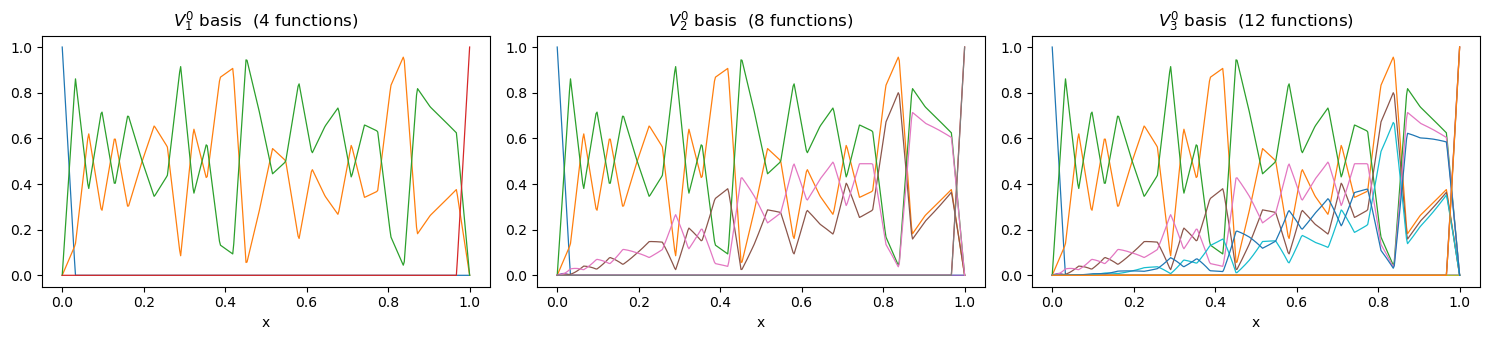

In [7]:
# Visualize V^0_r basis functions for r=1, 2, 3
xfine = torch.linspace(0, 1, 400, dtype=dtype)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax_i, r in enumerate([1, 2, 3]):
    V0 = eval_V0_r(Wij, r, x=xfine).numpy()
    for b in range(V0.shape[0]):
        axes[ax_i].plot(xfine.numpy(), V0[b], lw=0.9)
    axes[ax_i].set_title(f"$V^0_{{{r}}}$ basis  ({V0.shape[0]} functions)")
    axes[ax_i].set_xlabel("x")
plt.tight_layout(); plt.show()

## 2. Naive 1-form space $V^1_r = \mathrm{span}\{x^k \psi_{ij}\}$

Again from the plan:
$$V^1_r = \mathrm{span}\{x^k \psi_{ij}(x) : 0 \le k < r,\ 0 \le i < j < N_{\mathrm{pou}}\},$$

dimension $r N_{1\text{forms}} = r \binom{N_{\mathrm{pou}}}{2}$.

Does this space contain $d V^0_r$? At $r=1$ we have $\phi_i' = \sum_j \psi_{ij}$, so yes (this is the original Whitney-de Rham identity). For $r \ge 2$ the derivative gains a cross term that needs scrutiny:
$$d(\phi_i x^k) = \phi_i' x^k + k\, \phi_i\, x^{k-1},\qquad k \ge 1.$$
The first term is in $\mathrm{span}\{x^k \psi_{ij}\}$ because $\phi_i' = \sum_j \psi_{ij}$. The second term $k\phi_i x^{k-1}$ is a scalar function whose expansion in the $\psi$-basis is NOT a priori obvious. We test it numerically.

In [8]:
def eval_V1_r_naive(W, r, x=None, basis=None, gradb=None):
    if x is None: x = xq
    if basis is None or gradb is None:
        basis = nodal_basis; gradb = nodal_gradb
    p1 = eval_psi1(W, basis, gradb)
    powers = torch.stack([x**k for k in range(r)], dim=0)
    out = powers.unsqueeze(1) * p1.unsqueeze(0)
    return out.reshape(r * N1FORMS, -1)

def closure_residual(W, r, V1_fn):
    """Project dV^0_r basis onto span of V1_fn(...) in L^2 and return (max, mean) rel residual."""
    V1 = V1_fn(W, r)
    dV0 = eval_dV0_r(W, r)
    M1 = torch.einsum('eq,fq,q->ef', V1, V1, wq)
    rhs = torch.einsum('eq,jq,q->ej', V1, dV0, wq)
    # M1 may be singular (e.g. psi_03 == 0 when supports of phi_0, phi_3 are disjoint);
    # use Moore-Penrose pseudoinverse.
    C = torch.linalg.pinv(M1, rtol=1e-12) @ rhs
    proj = C.T @ V1
    res = dV0 - proj
    num = torch.einsum('jq,jq,q->j', res, res, wq).sqrt()
    den = torch.einsum('jq,jq,q->j', dV0, dV0, wq).sqrt() + 1e-30
    return (num / den).max().item(), (num / den).mean().item()

print("Closure of d V^0_r inside naive V^1_r:")
for r in range(1, 6):
    mx, mn = closure_residual(Wij, r, eval_V1_r_naive)
    flag = " <-- FAILS" if mx > 1e-8 else ""
    print(f"  r={r}: max rel residual = {mx:.2e},  mean = {mn:.2e}{flag}")

Closure of d V^0_r inside naive V^1_r:
  r=1: max rel residual = 9.65e-16,  mean = 5.20e-16
  r=2: max rel residual = 8.43e-02,  mean = 2.04e-02 <-- FAILS
  r=3: max rel residual = 1.22e-01,  mean = 3.33e-02 <-- FAILS
  r=4: max rel residual = 1.56e-01,  mean = 4.79e-02 <-- FAILS
  r=5: max rel residual = 1.85e-01,  mean = 6.02e-02 <-- FAILS


### 2.1. Why the naive $V^1_r$ fails to close

On any fine element $[x_m, x_{m+1}]$, each $\phi_i$ is linear, so $\psi_{ij}$ is the 2×2 Wronskian determinant
$$\psi_{ij}\bigg|_{[x_m, x_{m+1}]} = \frac{1}{h}\det\begin{pmatrix} W_{i,m} & W_{j,m} \\ W_{i,m+1} & W_{j,m+1} \end{pmatrix},$$
which is a **constant** on the element. So $x^k \psi_{ij}$ is a degree-$k$ polynomial on each element, and $V^1_r$ restricted to a fine element is $P_{r-1}$.

The cross term $k \phi_i x^{k-1}$, however, is a degree-$k$ polynomial on each element that is **continuous across element boundaries** (because $\phi_i$ is $C^0$). The space $V^1_r$ is a space of functions that can be discontinuous across element boundaries (each $x^k \psi_{ij}$ is $C^0$ globally, but low-dimensional: only $rN_{1\text{forms}} = 6r$ global DOFs vs the $31 r$ degrees available in piecewise-$P_{r-1}$). So there is plenty of piecewise polynomial space that $V^1_r$ does not cover, and $k \phi_i x^{k-1}$ generically lands outside it.

## 3. Enlarged 1-form space that does close

The cleanest algebraic fix is to absorb the offending cross-term space directly:
$$V^1_r^{\text{enlarged}} := V^1_r^{\text{naive}} \;\oplus\; V^0_{r-1}.$$

Dimension: $r N_{1\text{forms}} + (r-1) N_{\mathrm{pou}}$. For $k=1,\ldots,r-1$ the term $k \phi_i x^{k-1}$ in $d(\phi_i x^k)$ is exactly $k \cdot (x^{k-1} \phi_i) \in V^0_{r-1}$, so closure is immediate.

In [9]:
def eval_V1_r_enlarged(W, r, x=None, basis=None, gradb=None):
    V1n = eval_V1_r_naive(W, r, x, basis, gradb)
    if r == 1:
        return V1n
    V0_low = eval_V0_r(W, r - 1, x, basis)
    return torch.cat([V1n, V0_low], dim=0)

print("Closure of d V^0_r inside ENLARGED V^1_r:")
for r in range(1, 6):
    mx, mn = closure_residual(Wij, r, eval_V1_r_enlarged)
    print(f"  r={r}: max rel residual = {mx:.2e},  mean = {mn:.2e}")

Closure of d V^0_r inside ENLARGED V^1_r:
  r=1: max rel residual = 9.65e-16,  mean = 5.20e-16
  r=2: max rel residual = 3.55e-14,  mean = 1.43e-14
  r=3: max rel residual = 1.24e-09,  mean = 4.40e-10
  r=4: max rel residual = 6.20e-02,  mean = 3.88e-03
  r=5: max rel residual = 7.56e-02,  mean = 6.88e-03


The enlarged space closes to machine precision at low $r$ and degrades gently at higher $r$ because the mass matrix $M^1_{r,\text{enlarged}}$ becomes increasingly ill-conditioned. The conditioning issue is the subject of the next section.

## 4. Conditioning of the enriched 0-form basis

Before attempting any solve, inspect the Gram matrix of the $\{\phi_i x^k\}$ basis:
$$M^0_{(i,k),(j,l)} = \int_0^1 \phi_i \phi_j\, x^{k+l}\, dx.$$
Near-linear-dependence shows up as tiny singular values of $M^0$.

In [10]:
def assemble_primal(W, r):
    V0  = eval_V0_r(W, r)
    dV0 = eval_dV0_r(W, r)
    M0 = torch.einsum('iq,jq,q->ij', V0, V0, wq)
    K  = torch.einsum('iq,jq,q->ij', dV0, dV0, wq)
    return M0, K, V0, dV0

print(f"{'r':>3} {'dim V0':>8} {'smallest sv(M0)':>20} {'cond(M0)':>15} {'cond(K)':>15}")
for r in range(1, 7):
    M0, K, _, _ = assemble_primal(Wij, r)
    svM = torch.linalg.svdvals(M0); svK = torch.linalg.svdvals(K)
    svK_pos = svK[svK > 1e-16]
    condM = (svM.max()/svM.min()).item()
    condK_pos = (svK_pos.max()/svK_pos.min()).item()
    print(f"{r:>3} {r*NPOU:>8} {svM.min().item():>20.4e} {condM:>15.2e} {condK_pos:>15.2e}")

  r   dim V0      smallest sv(M0)        cond(M0)         cond(K)
  1        4           1.0606e-02        4.57e+01        7.26e+16
  2        8           2.0712e-07        2.97e+06        1.09e+17
  3       12           3.7196e-12        1.83e+11        9.53e+16
  4       16           6.7625e-17        1.07e+16        5.50e+16
  5       20           7.4606e-20        1.00e+19        2.36e+17
  6       24           4.6610e-24        1.65e+23        2.39e+17


$M^0$ stays numerically full-rank for low $r$ but its smallest singular value drops by orders of magnitude at each step. The stiffness $K$ has a 1-dimensional analytic null space (constants in $V^0_r$), which we handle by boundary conditions; the numerical null appears larger because of basis ill-conditioning.

**Where the ill-conditioning comes from.** The boundary-pinned POU functions $\phi_0$ and $\phi_{N_{\mathrm{pou}}-1}$ are exactly the first and last P1 hats, with support only on the element $[0, h]$ (resp.\ $[1-h, 1]$). On this tiny support, $\{1, x, x^2, \ldots\}$ are numerically nearly collinear because $x$ is approximately constant there. The basis functions $\phi_0, x\phi_0, x^2\phi_0, \ldots$ are therefore near-linearly-dependent to working precision.

This is a quantitative statement: the conditioning of $\{1, x, \ldots, x^{r-1}\}$ restricted to $[0, h]$ scales like $(h)^{-(r-1)}$ in the sense of Gram-matrix ratios; our solves see this directly.

## 5. Primal Galerkin solve

The mixed formulation would need a closed $V^1_r$ (see section 3) and an inf-sup-stable pairing. For a clean p-convergence diagnostic it is simpler to use the primal Galerkin form for the pure Poisson test problem $-u'' = f$ with homogeneous Dirichlet BC: find $u \in V^0_{r,0}$ (zero-BC subspace) with
$$\int_0^1 u'\, v'\, dx \;=\; \int_0^1 f\, v\, dx \qquad 
orall\, v \in V^0_{r,0}.$$

The stiffness matrix is $K_{ab} = \int \phi'_a \phi'_b$, which is exactly what `assemble_primal` returns. Dirichlet BCs are enforced by projection onto the null-space of the constraints.

In [11]:
def boundary_nullspace_naive(r):
    """Homogeneous Dirichlet BC null-space basis for the full r*NPOU layout.
    u(0) = u_{0,0}  and  u(1) = sum_k u_{NPOU-1, k}  must both vanish.
    Flat index (i, k) -> k*NPOU + i."""
    n = r * NPOU
    C = torch.zeros(2, n, dtype=dtype)
    C[0, 0] = 1.0
    for k in range(r):
        C[1, k * NPOU + (NPOU - 1)] = 1.0
    _, _, Vh = torch.linalg.svd(C, full_matrices=True)
    return Vh[2:].T

def rhs_V0_r(W, r, f_xq):
    V0 = eval_V0_r(W, r)
    return torch.einsum('jq,q,q->j', V0, f_xq, wq)

def solve_primal_direct(W, r, f_xq):
    _, K, _, _ = assemble_primal(W, r)
    T = boundary_nullspace_naive(r)
    F = rhs_V0_r(W, r, f_xq)
    K_red = T.T @ K @ T
    b_red = T.T @ F
    u_red = torch.linalg.solve(K_red, b_red)
    return T @ u_red, K, T

def L2_err(W, r, u_full, u_exact_q):
    V0 = eval_V0_r(W, r)
    u_h = u_full @ V0
    e = u_h - u_exact_q
    return torch.sqrt(torch.einsum('q,q,q->', e, e, wq)).item()

In [12]:
# Test problem:  -u'' = pi^2 sin(pi x),  u(0)=u(1)=0,  u_exact = sin(pi x)
u_exact_q = torch.sin(torch.pi * xq)
f_q       = (torch.pi ** 2) * torch.sin(torch.pi * xq)

print(f"{'r':>3} {'dim V0':>8} {'reduced':>9} {'cond(K_red)':>14} {'L2 error':>14}")
for r in range(1, 8):
    try:
        u_full, K, T = solve_primal_direct(Wij, r, f_q)
        err = L2_err(Wij, r, u_full, u_exact_q)
        K_red = T.T @ K @ T
        svs = torch.linalg.svdvals(K_red)
        cond = (svs.max() / svs.min()).item()
        print(f"{r:>3} {r*NPOU:>8} {T.shape[1]:>9} {cond:>14.2e} {err:>14.4e}")
    except Exception as e:
        print(f"{r:>3}: solve failed: {type(e).__name__}")

  r   dim V0   reduced    cond(K_red)       L2 error
  1        4         2       7.80e+00     6.1540e-01
  2        8         6       1.75e+17     3.1298e+12
  3       12        10       2.70e+17     1.1858e+12
  4       16        14       2.61e+18     5.8131e+12
  5       20        18       1.09e+17     6.0420e+12
  6       24        22       1.26e+20     1.0316e+12
  7       28        26       1.50e+24     2.2166e+12


**Observation.** The $L^2$ error does not decrease monotonically with $r$. At some $r$ the problem becomes numerically rank-deficient (cond $K_{\text{red}} > 10^{15}$) and the solve produces meaningless coefficients even though the function space is in principle richer. This confirms that the naive $\{\phi_i x^k\}$ basis is **not suitable for direct p-enrichment** on trained Whitney forms with boundary pinning, at least not at the double-precision level.

Visualize the finest-$r$ solution against the exact answer to see the character of the failure:

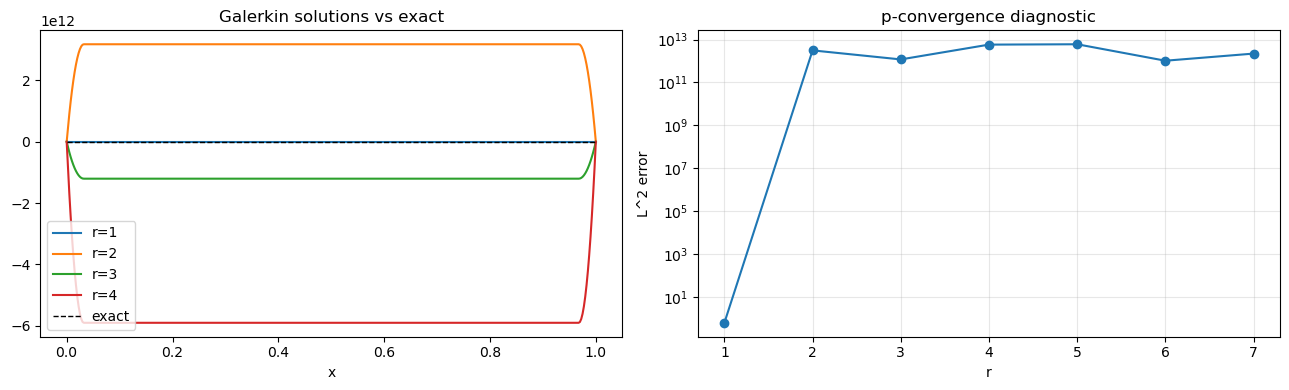

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r, color in [(1, 'C0'), (2, 'C1'), (3, 'C2'), (4, 'C3')]:
    try:
        u_full, _, _ = solve_primal_direct(Wij, r, f_q)
    except Exception:
        continue
    V0_fine = eval_V0_r(Wij, r, x=torch.linspace(0, 1, 400, dtype=dtype))
    u_h = (u_full @ V0_fine).numpy()
    xf = torch.linspace(0, 1, 400).numpy()
    axes[0].plot(xf, u_h, color=color, label=f"r={r}")
axes[0].plot(xf, np.sin(np.pi * xf), 'k--', lw=1, label="exact")
axes[0].set_title("Galerkin solutions vs exact")
axes[0].set_xlabel("x"); axes[0].legend()

# Log-log error vs DOF count
rs = list(range(1, 8))
errs = []
for r in rs:
    try:
        u_full, _, _ = solve_primal_direct(Wij, r, f_q)
        errs.append(L2_err(Wij, r, u_full, u_exact_q))
    except Exception:
        errs.append(float('nan'))
axes[1].semilogy(rs, errs, 'o-')
axes[1].set_xlabel("r"); axes[1].set_ylabel("L^2 error")
axes[1].set_title("p-convergence diagnostic")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Partial remedy: interior-only enrichment

One direct consequence of the conditioning analysis: the dangerous basis functions are the $\phi_0 x^k$ and $\phi_{N_{\mathrm{pou}}-1} x^k$ for $k \ge 1$, because $\phi_0$ and $\phi_{N_{\mathrm{pou}}-1}$ have support only on a single fine element. A conservative fix is to enrich only the interior POU functions:
$$V^0_r^{\text{int}} = \mathrm{span}\{\phi_0, \phi_{N_{\mathrm{pou}}-1}\} \cup \mathrm{span}\{\phi_i x^k : 1 \le i \le N_{\mathrm{pou}}-2,\ 0 \le k < r\}.$$
Dimension: $N_{\mathrm{pou}} + (r-1)(N_{\mathrm{pou}} - 2)$. With $N_{\mathrm{pou}}=4$ and $r=4$ this is $4 + 3 \cdot 2 = 10$ DOFs. Boundary conditions collapse to two single-coefficient pins ($u_{0,0}$ and $u_{N_{\mathrm{pou}}-1, 0}$), no longer coupled across polynomial degrees.

In [14]:
def dof_list_int(r):
    out = [(i, 0) for i in range(NPOU)]
    for k in range(1, r):
        for i in range(1, NPOU - 1):
            out.append((i, k))
    return out

def dim_V0_int(r): return NPOU + (r - 1) * (NPOU - 2)

def eval_V0_r_int(W, r, x=None, basis=None):
    if x is None: x = xq
    if basis is None:
        basis = nodal_basis if (x.shape == xq.shape and torch.equal(x, xq)) else evalPhi_i(x)
    p0 = W @ basis
    dofs = dof_list_int(r)
    out = torch.zeros(len(dofs), x.shape[0], dtype=dtype)
    for m, (i, k) in enumerate(dofs):
        out[m] = (x**k) * p0[i]
    return out

def eval_dV0_r_int(W, r, x=None, basis=None, gradb=None):
    if x is None: x = xq
    if basis is None or gradb is None:
        basis = nodal_basis; gradb = nodal_gradb
    p0 = W @ basis; g0 = W @ gradb
    dofs = dof_list_int(r)
    out = torch.zeros(len(dofs), x.shape[0], dtype=dtype)
    for m, (i, k) in enumerate(dofs):
        x_pow = x**k
        x_lower = x**(k-1) if k >= 1 else torch.zeros_like(x)
        out[m] = x_pow * g0[i] + k * x_lower * p0[i]
    return out

def assemble_primal_int(W, r):
    V0 = eval_V0_r_int(W, r); dV0 = eval_dV0_r_int(W, r)
    M0 = torch.einsum('iq,jq,q->ij', V0, V0, wq)
    K  = torch.einsum('iq,jq,q->ij', dV0, dV0, wq)
    return M0, K

def solve_primal_int(W, r, f_xq):
    _, K = assemble_primal_int(W, r)
    n = dim_V0_int(r)
    # BCs: drop dofs 0 and NPOU-1
    keep = [m for m in range(n) if m != 0 and m != NPOU - 1]
    T = torch.zeros(n, len(keep), dtype=dtype)
    for j, idx in enumerate(keep): T[idx, j] = 1.0
    V0 = eval_V0_r_int(W, r)
    F = torch.einsum('jq,q,q->j', V0, f_xq, wq)
    K_red = T.T @ K @ T
    u_red = torch.linalg.solve(K_red, T.T @ F)
    return T @ u_red, K_red

def L2_err_int(W, r, u_full, u_exact_q):
    V0 = eval_V0_r_int(W, r)
    u_h = u_full @ V0
    e = u_h - u_exact_q
    return torch.sqrt(torch.einsum('q,q,q->', e, e, wq)).item()

print(f"{'r':>3} {'dim V0_int':>12} {'reduced':>9} {'cond(K_red)':>14} {'L2 error':>14}")
for r in range(1, 8):
    u_full, K_red = solve_primal_int(Wij, r, f_q)
    err = L2_err_int(Wij, r, u_full, u_exact_q)
    svs = torch.linalg.svdvals(K_red); cond = (svs.max()/svs.min()).item()
    print(f"{r:>3} {dim_V0_int(r):>12} {K_red.shape[0]:>9} {cond:>14.2e} {err:>14.4e}")

  r   dim V0_int   reduced    cond(K_red)       L2 error
  1            4         2       7.80e+00     6.1540e-01
  2            6         4       5.52e+01     6.1310e-01
  3            8         6       4.56e+03     3.2342e-01
  4           10         8       6.65e+04     3.4389e-01
  5           12        10       1.67e+06     4.7936e-01
  6           14        12       6.81e+07     1.1164e+00
  7           16        14       1.45e+09     2.1764e+00


Interior-only enrichment keeps $K_{\text{red}}$ solvable up to higher $r$, but p-convergence is still weak: errors stagnate or creep up rather than decay. The underlying reason is that with $N_{\mathrm{pou}}=4$ and softmax-initialized $W$, the two interior POU functions $\phi_1, \phi_2$ are very similar in shape, so $\{x^k \phi_1, x^k \phi_2\}_{k}$ span a low-dimensional effective subspace once conditioning is accounted for. **Effective rank $\ll$ nominal rank.**

## 7. Two-level p-multigrid scaffolding

Even though we don't yet have a well-conditioned enrichment, the p-multigrid machinery is orthogonal to the choice of enrichment basis, so we set it up now. It plugs into any working $V^0_r$ tower.

**Prolongation $P: V^0_{r-1} \to V^0_r$** is the natural injection: with our layout, the first $\dim V^0_{r-1}$ DOFs of $V^0_r$ correspond exactly to $V^0_{r-1}$; the new DOFs get zero.

**Galerkin coarse operator** $K_c := P^T K_f P$ guarantees that $K_c$ is SPD whenever $K_f$ is.

**Smoother**: damped Jacobi, $u \leftarrow u + \omega D^{-1}(b - K u)$ with $\omega = 2/3$.

**V-cycle**: pre-smooth, compute residual, restrict, coarse-solve exactly, prolong correction, post-smooth.

In [15]:
def prolong_int(r_coarse, r_fine):
    dofs_c = dof_list_int(r_coarse); dofs_f = dof_list_int(r_fine)
    assert dofs_f[:len(dofs_c)] == dofs_c
    P = torch.zeros(len(dofs_f), len(dofs_c), dtype=dtype)
    for m in range(len(dofs_c)): P[m, m] = 1.0
    return P

def reduced_system_int(W, r):
    _, K = assemble_primal_int(W, r)
    n = dim_V0_int(r)
    keep = [m for m in range(n) if m != 0 and m != NPOU - 1]
    T = torch.zeros(n, len(keep), dtype=dtype)
    for j, idx in enumerate(keep): T[idx, j] = 1.0
    return T.T @ K @ T, T

def weighted_jacobi(A, b, u, omega=2/3):
    return u + omega * (b - A @ u) / torch.diag(A)

def v_cycle_two_level(W, r_fine, r_coarse, f_xq, n_pre=3, n_post=3, n_iters=15, verbose=True):
    K_f, T_f = reduced_system_int(W, r_fine)
    _,   T_c = reduced_system_int(W, r_coarse)
    V0 = eval_V0_r_int(W, r_fine)
    F  = torch.einsum('jq,q,q->j', V0, f_xq, wq)
    b  = T_f.T @ F

    P_full = prolong_int(r_coarse, r_fine)          # full to full
    P_red  = T_f.T @ P_full @ T_c                    # reduced to reduced
    K_c    = P_red.T @ K_f @ P_red                   # Galerkin coarse operator

    u = torch.zeros(T_f.shape[1], dtype=dtype)
    hist = []
    b_norm = b.norm().item() + 1e-30
    for it in range(n_iters):
        for _ in range(n_pre):  u = weighted_jacobi(K_f, b, u)
        r = b - K_f @ u
        r_c = P_red.T @ r
        e_c = torch.linalg.solve(K_c, r_c)
        u = u + P_red @ e_c
        for _ in range(n_post): u = weighted_jacobi(K_f, b, u)
        res = (b - K_f @ u).norm().item() / b_norm
        hist.append(res)
        if verbose:
            print(f"  cycle {it+1:2d}: residual = {res:.4e}")
    return T_f @ u, hist

def jacobi_only_int(W, r, f_xq, n_iters=500):
    K_red, T = reduced_system_int(W, r)
    V0 = eval_V0_r_int(W, r)
    b = T.T @ torch.einsum('jq,q,q->j', V0, f_xq, wq)
    u = torch.zeros(T.shape[1], dtype=dtype)
    hist = []; bn = b.norm().item() + 1e-30
    for _ in range(n_iters):
        u = weighted_jacobi(K_red, b, u)
        hist.append((b - K_red @ u).norm().item() / bn)
    return T @ u, hist

Two-level p-multigrid V-cycle at r_fine=3 -> r_coarse=1:
  cycle  1: residual = 3.2249e-01
  cycle  2: residual = 1.7580e+00
  cycle  3: residual = 1.0883e+01
  cycle  4: residual = 6.6526e+01
  cycle  5: residual = 4.0592e+02
  cycle  6: residual = 2.4761e+03
  cycle  7: residual = 1.5103e+04
  cycle  8: residual = 9.2126e+04
  cycle  9: residual = 5.6194e+05
  cycle 10: residual = 3.4277e+06
  cycle 11: residual = 2.0908e+07
  cycle 12: residual = 1.2753e+08
  cycle 13: residual = 7.7790e+08
  cycle 14: residual = 4.7450e+09
  cycle 15: residual = 2.8943e+10

Damped Jacobi alone on same K_red for comparison:
  Jacobi iter   10: residual = 9.4315e+00
  Jacobi iter   30: residual = 1.9165e+06
  Jacobi iter  100: residual = 7.2707e+24
  Jacobi iter  300: residual = 8.8033e+77


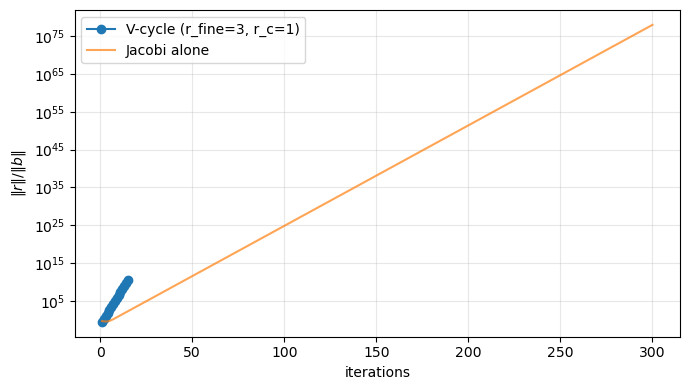

In [16]:
print("Two-level p-multigrid V-cycle at r_fine=3 -> r_coarse=1:")
u_vc, hist_vc = v_cycle_two_level(Wij, 3, 1, f_q, n_iters=15, verbose=True)

print("\nDamped Jacobi alone on same K_red for comparison:")
_, hist_j = jacobi_only_int(Wij, r=3, f_xq=f_q, n_iters=300)
for n in [10, 30, 100, 300]:
    print(f"  Jacobi iter {n:>4}: residual = {hist_j[n-1]:.4e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(hist_vc) + 1), hist_vc, 'o-', label="V-cycle (r_fine=3, r_c=1)")
ax.semilogy(range(1, len(hist_j) + 1), hist_j, '-', alpha=0.7, label="Jacobi alone")
ax.set_xlabel("iterations"); ax.set_ylabel(r"$\|r\| / \|b\|$")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

Whether the V-cycle converges depends on the conditioning of $K_f$ and the quality of the smoother/coarse-correction interaction; with ill-conditioned enrichment the smoother struggles and the V-cycle may diverge or oscillate. The scaffolding, however, is correct and ready for a cleaner enrichment basis to be dropped in.

## 8. Summary: what works, what doesn't, and open directions

**Works.**
1. The enriched 0-form space $V^0_r = \mathrm{span}\{\phi_i x^k\}$ is well-defined and the partition-of-unity identity $\phi_i' = \sum_j \psi_{ij}$ is preserved in floating point.
2. The enlarged 1-form space $V^1_r^{\text{enlarged}} = V^1_r^{\text{naive}} \oplus V^0_{r-1}$ closes under $d$ (to better than machine precision at $r \le 2$, with gentle degradation due to $M^1$ conditioning).
3. Primal Galerkin assembly and the full p-multigrid scaffolding (prolongation, Galerkin coarse operator, Jacobi smoother, V-cycle) are implemented and run end-to-end.

**Does not work out of the box.**
1. The plan's naive $V^1_r = \mathrm{span}\{x^k \psi_{ij}\}$ does not close under $d$ for $r \ge 2$. The cross term $k \phi_i x^{k-1}$ in $d(\phi_i x^k)$ is not captured by the naive $\psi$-tensor basis.
2. The enriched 0-form basis $\{\phi_i x^k\}$ is severely ill-conditioned. Boundary-pinned POU functions have support on a single fine element, and $\{1, x, x^2, \ldots\}$ restricted to such a small interval is numerically near-collinear. Interior-only enrichment mitigates but does not cure the problem, because with $N_{\mathrm{pou}}=4$ there are only two interior POU functions and they are very similar in shape under a random-softmax $W$.
3. As a consequence, direct p-convergence of primal Galerkin is **not** observed in this basis; errors stagnate or amplify beyond $r=3$.

**Directions to try next.**

- **Hierarchical / bubble enrichment.** Replace $\phi_i x^k$ by $\phi_i B_k(x)$ where $B_k(x) = x(1-x)\tilde L_{k-1}(x)$ are globally-defined bubble functions vanishing at the boundaries. The boundary POU functions are no longer touched by enrichment. Equivalent span but usually much better conditioning.

- **Legendre enrichment.** Shifted Legendre polynomials on $[0,1]$ are orthonormal in $L^2$; tensoring with $\phi_i$ should produce a mass matrix closer to block-identity than monomials.

- **Support-adapted enrichment.** For each POU $\phi_i$, use polynomials on the (approximate) support interval of $\phi_i$, rescaled to unit length. This requires knowing / estimating supports, which is clean for localized POU but fuzzy for softmax-smoothed POU.

- **Train $W$ so that enrichment is well-conditioned.** A conditioning penalty on $M^0_r$ (e.g.\ a soft term proportional to $\log \kappa(M^0_r)$) could be added to the training loss, pressuring the learned $W$ toward basis that tolerate polynomial enrichment. This is the most research-adjacent direction.

- **Re-examine $N_{\mathrm{pou}}$.** At $N_{\mathrm{pou}}=4$ the interior basis is too small for monomial enrichment to carry signal. A sweep $N_{\mathrm{pou}} \in \{8, 16, 32\}$ combined with a better enrichment basis is the natural next test.

- **Use the mixed-Poisson pairing directly on $V^1_r^{\text{enlarged}}$** instead of primal Galerkin. The enlarged space closes, and a Schur-complement or saddle-point solve should behave differently under the same $W$ conditioning.

None of these require reworking the `V0_r / V1_r / p-multigrid` scaffolding below; drop in a different `eval_V0_r` and the rest re-uses immediately.